
# Stock Price Prediction using LSTM

This notebook demonstrates how to build an LSTM (Long Short-Term Memory) model for stock price prediction using TensorFlow/Keras.


In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [2]:
stock_symbol = 'AAPL'

data = yf.download(stock_symbol, start='2015-01-01', end='2024-01-01')

data.head()


/tmp/ipykernel_5145/2467288524.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2015-01-06,23.513279,23.772177,23.152590,23.575237,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [3]:
dataset = data['Close'].values
dataset = dataset.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

scaled_data[:5]


array([[0.0206856 ],
       [0.01679834],
       [0.01681097],
       [0.01869147],
       [0.02391657]])

In [4]:
training_data_len = int(np.ceil(len(scaled_data) * 0.8))

train_data = scaled_data[0:int(training_data_len), :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)


x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(x_train.shape)


(1752, 60, 1)


In [5]:

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))

model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10
)


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.1809e-04
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 3.2353e-04
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 3.3674e-04
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.8521e-04
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.7745e-04
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.8182e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 2.5743e-04
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.7540e-04
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 2.7450e-04
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.3365e-04


In [8]:

test_data = scaled_data[training_data_len - 60:, :]

x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)


x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


In [12]:
from sklearn.metrics import r2_score


rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print("RMSE:", rmse)

r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

RMSE: 5.095192704172482
R2 Score: 0.9238738253233149


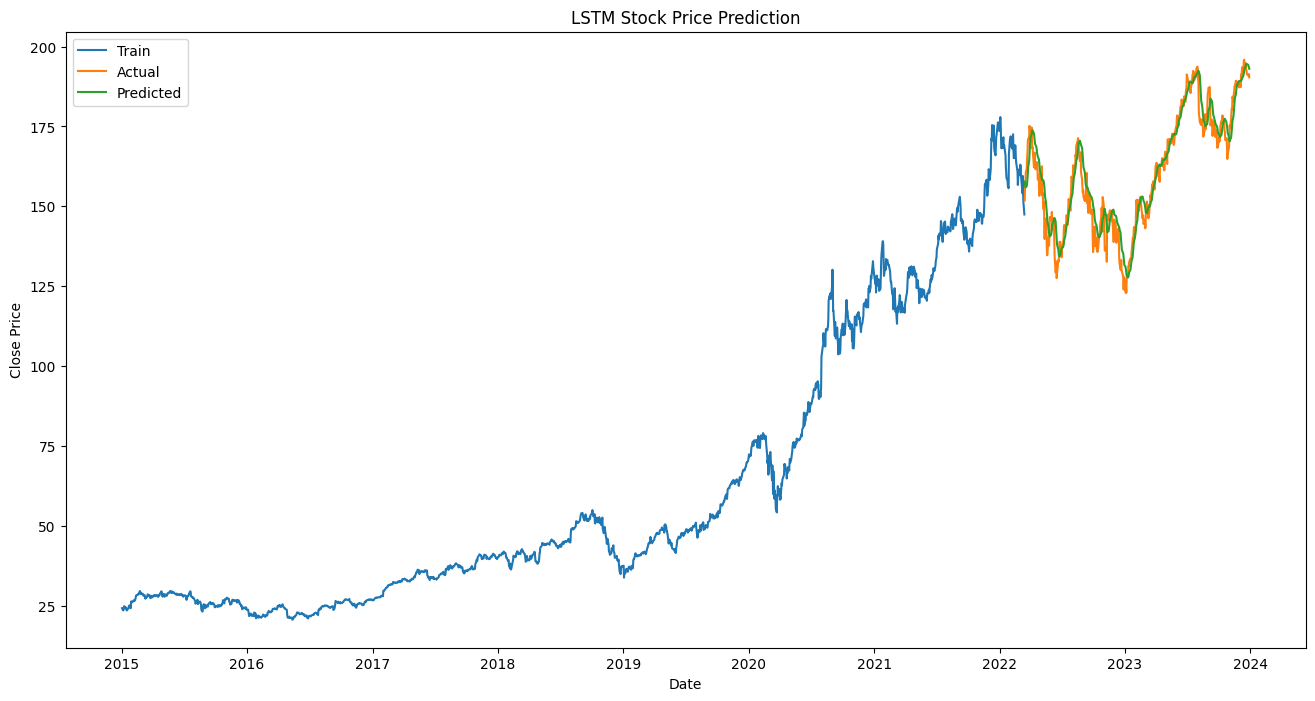

In [10]:

train = data[:training_data_len]
valid = data[training_data_len:].copy()

valid['Predictions'] = predictions

plt.figure(figsize=(16,8))

plt.title('LSTM Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])

plt.legend(['Train', 'Actual', 'Predicted'])

plt.show()


In [11]:

last_60_days = scaled_data[-60:]

X_test = []
X_test.append(last_60_days[:, 0])

X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

pred_price = model.predict(X_test)

pred_price = scaler.inverse_transform(pred_price)

print("Predicted Next Day Price:", pred_price[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Next Day Price: 192.65039
